<h1 style="
    text-align:center;
    background-color:#1A5276;
    color:white;
    padding:20px;
    border-radius:10px;">
    ⛽📊 Petrol Consumption — Full EDA, KPI & Decision Tree Classifier Report
</h1>
<p style="text-align:center;color:#1F4E79;font-size:1rem;margin-top:10px;">
<b>Records:</b> 48 &nbsp;|&nbsp; <b>Features:</b> 4 &nbsp;|&nbsp; <b>Target:</b> Petrol Consumption (High / Low) &nbsp;|&nbsp; <b>Model:</b> Decision Tree Classifier
</p>


<h2 style="color:#2E86C1;">
 1️⃣ 📚 Import Libraries
</h2>

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import GridSearchCV

import pickle

import warnings


warnings.filterwarnings('ignore')

<h2 style="color:#2E86C1;">
2️⃣ 🎯📖 Reading Dataset
</h2>

In [57]:
data = pd.read_csv('petrol_consumption.csv')
df   = data.copy()
df.head()

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,9.0,3571,1976,0.525,541
1,9.0,4092,1250,0.572,524
2,9.0,3865,1586,0.580,561
3,7.5,4870,2351,0.529,414
4,8.0,4399,431,0.544,410


<h2 style="color:#2E86C1;">
3️⃣ 𝄜 Data Shape
</h2>

In [58]:
print(f"  𝄜 Data Shape : {df.shape}")

  𝄜 Data Shape : (48, 5)


In [4]:
print(f'(☰)  Number of rows: {df.shape[0]}')
print(f'(|||) Number of columns: {df.shape[1]}')

(☰)  Number of rows: 48
(|||) Number of columns: 5


<h2 style="color:#2E86C1;">
4️⃣ 🔍 Initial Data Exploration
</h2>

In [59]:
print('📌 First 10 rows of the dataset:')
df.head(10)

📌 First 10 rows of the dataset:


,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,9.0,3571,1976,0.525,541
1,9.0,4092,1250,0.572,524
2,9.0,3865,1586,0.580,561
3,7.5,4870,2351,0.529,414
4,8.0,4399,431,0.544,410
5,10.0,5342,1333,0.571,457
6,8.0,5319,11868,0.451,344
7,8.0,5126,2138,0.553,467
8,8.0,4447,8577,0.529,464
9,7.0,4512,8507,0.552,498


In [60]:
print('📌 Last 5 rows of the dataset:')
df.tail()

📌 Last 5 rows of the dataset:


,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
43,7.0,3745,2611,0.508,591
44,6.0,5215,2302,0.672,782
45,9.0,4476,3942,0.571,510
46,7.0,4296,4083,0.623,610
47,7.0,5002,9794,0.593,524


In [61]:
print("\n" + "="*50 + "\n")
print('📋 Dataset Information:')
print(df.info())
print("\n" + "="*50 + "\n")



📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Petrol_tax                    48 non-null     float64
 1   Average_income                48 non-null     int64  
 2   Paved_Highways                48 non-null     int64  
 3   Population_Driver_licence(%)  48 non-null     float64
 4   Petrol_Consumption            48 non-null     int64  
dtypes: float64(2), int64(3)
memory usage: 2.0 KB
None




In [62]:
print("\n" + "="*100 + "\n")
print('📝 Column Names:')
print(df.columns.tolist())
print("\n" + "="*100 + "\n")



📝 Column Names:
['Petrol_tax', 'Average_income', 'Paved_Highways', 'Population_Driver_licence(%)', 'Petrol_Consumption']




In [63]:
print('📊 Descriptive Statistics (Numerical):')
df.describe().T

📊 Descriptive Statistics (Numerical):


,count,mean,std,min,25%,50%,75%,max
Petrol_tax,48.0,7.668333,0.950770,5.000,7.00000,7.5000,8.12500,10.000
Average_income,48.0,4241.833333,573.623768,3063.000,3739.00000,4298.0000,4578.75000,5342.000
Paved_Highways,48.0,5565.416667,3491.507166,431.000,3110.25000,4735.5000,7156.00000,17782.000
Population_Driver_licence(%),48.0,0.570333,0.055470,0.451,0.52975,0.5645,0.59525,0.724
Petrol_Consumption,48.0,576.770833,111.885816,344.000,509.50000,568.5000,632.75000,968.000


<h2 style="color:#2E86C1;">
5️⃣ 🧹 Data Cleaning & Preprocessing
</h2>

💡 All 5 columns are **numerical** — no missing values detected.

Added helper columns: `consumption_label`, `tax_group`, `income_level`, `highway_level`, `license_level` for richer analysis.


In [64]:
# Create binary target: High / Low based on median
median_consumption       = df['Petrol_Consumption'].median()
df['Consumption_Class']  = (df['Petrol_Consumption'] >= median_consumption).astype(int)
df['consumption_label']  = df['Consumption_Class'].map({1: 'High', 0: 'Low'})

# Helper grouping columns
df['tax_group'] = pd.cut(
    df['Petrol_tax'],
    bins=[0, 7, 8, 10],
    labels=['Low Tax (<7)', 'Mid Tax (7-8)', 'High Tax (>8)']
)

df['income_level'] = pd.cut(
    df['Average_income'],
    bins=[0, 4000, 5000, 6000, 10000],
    labels=['Low (<4K)', 'Mid (4-5K)', 'Upper-Mid (5-6K)', 'High (>6K)']
)

df['highway_level'] = pd.cut(
    df['Paved_Highways'],
    bins=[0, 3000, 6000, 9000, 20000],
    labels=['Low (<3K)', 'Mid (3-6K)', 'High (6-9K)', 'Very High (>9K)']
)

df['license_level'] = pd.cut(
    df['Population_Driver_licence(%)'],
    bins=[0, 0.50, 0.55, 0.60, 1.0],
    labels=['Low (<50%)', 'Mid (50-55%)', 'High (55-60%)', 'Very High (>60%)']
)

df.head(3)

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption,Consumption_Class,consumption_label,tax_group,income_level,highway_level,license_level
0,9.0,3571,1976,0.525,541,0,Low,High Tax (>8),Low (<4K),Low (<3K),Mid (50-55%)
1,9.0,4092,1250,0.572,524,0,Low,High Tax (>8),Mid (4-5K),Low (<3K),High (55-60%)
2,9.0,3865,1586,0.580,561,0,Low,High Tax (>8),Low (<4K),Low (<3K),High (55-60%)


In [65]:
print('❌ Missing Values in Each Column:')
null_counts = df.isnull().sum()
print(null_counts)

❌ Missing Values in Each Column:
Petrol_tax                      0
Average_income                  0
Paved_Highways                  0
Population_Driver_licence(%)    0
Petrol_Consumption              0
Consumption_Class               0
consumption_label               0
tax_group                       0
income_level                    0
highway_level                   0
license_level                   0
dtype: int64


In [66]:
duplicates_count = df.duplicated().sum()
print(f'🔍 Number of Duplicate Rows: {duplicates_count}')

🔍 Number of Duplicate Rows: 0


In [67]:
duplicates_count = df.T.duplicated().sum()
print(f'🔍 Number of Duplicate Columns: {duplicates_count}')

🔍 Number of Duplicate Columns: 0


## IMPORTANT KPI 

In [68]:
print('='*60)
print('  DATASET OVERVIEW')
print('='*60)
print(f'  Total Records            : {df.shape[0]}')
print(f'  Tax Groups               : {df["tax_group"].nunique()}  -> {list(df["tax_group"].cat.categories)}')
print(f'  Income Levels            : {df["income_level"].nunique()}  -> {list(df["income_level"].cat.categories)}')
print(f'  Highway Levels           : {df["highway_level"].nunique()}  -> {list(df["highway_level"].cat.categories)}')
print(f'  License Levels           : {df["license_level"].nunique()}  -> {list(df["license_level"].cat.categories)}')
print(f'  High Consumption (>=med) : {df["Consumption_Class"].sum()}  ({df["Consumption_Class"].mean()*100:.1f}%)')
print(f'  Low Consumption  (<med)  : {(df["Consumption_Class"]==0).sum()}  ({(1-df["Consumption_Class"].mean())*100:.1f}%)')
print(f'  Avg Petrol Tax           : {df["Petrol_tax"].mean():.2f}')
print(f'  Avg Average Income       : {df["Average_income"].mean():,.0f}')
print(f'  Avg Paved Highways       : {df["Paved_Highways"].mean():,.0f}')
print(f'  Avg Driver Licence (%)   : {df["Population_Driver_licence(%)"].mean()*100:.2f}%')
print(f'  Avg Petrol Consumption   : {df["Petrol_Consumption"].mean():.1f}')
print('='*60)

  DATASET OVERVIEW
  Total Records            : 48
  Tax Groups               : 3  -> ['Low Tax (<7)', 'Mid Tax (7-8)', 'High Tax (>8)']
  Income Levels            : 3  -> ['Low (<4K)', 'Mid (4-5K)', 'Upper-Mid (5-6K)', 'High (>6K)']
  Highway Levels           : 4  -> ['Low (<3K)', 'Mid (3-6K)', 'High (6-9K)', 'Very High (>9K)']
  License Levels           : 4  -> ['Low (<50%)', 'Mid (50-55%)', 'High (55-60%)', 'Very High (>60%)']
  High Consumption (>=med) : 24  (50.0%)
  Low Consumption  (<med)  : 24  (50.0%)
  Avg Petrol Tax           : 7.67
  Avg Average Income       : 4,242
  Avg Paved Highways       : 5,565
  Avg Driver Licence (%)   : 57.03%
  Avg Petrol Consumption   : 576.8


In [15]:
print('📊 Descriptive Statistics (Numerical):')
df.describe().T

📊 Descriptive Statistics (Numerical):


,count,mean,std,min,25%,50%,75%,max
Petrol_tax,48.0,7.668333,0.950770,5.000,7.00000,7.5000,8.12500,10.000
Average_income,48.0,4241.833333,573.623768,3063.000,3739.00000,4298.0000,4578.75000,5342.000
Paved_Highways,48.0,5565.416667,3491.507166,431.000,3110.25000,4735.5000,7156.00000,17782.000
Population_Driver_licence(%),48.0,0.570333,0.055470,0.451,0.52975,0.5645,0.59525,0.724
Petrol_Consumption,48.0,576.770833,111.885816,344.000,509.50000,568.5000,632.75000,968.000
Consumption_Class,48.0,0.500000,0.505291,0.000,0.00000,0.5000,1.00000,1.000


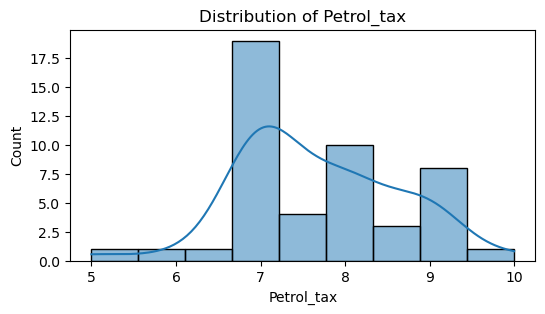

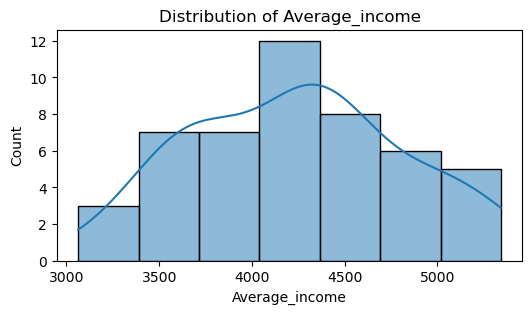

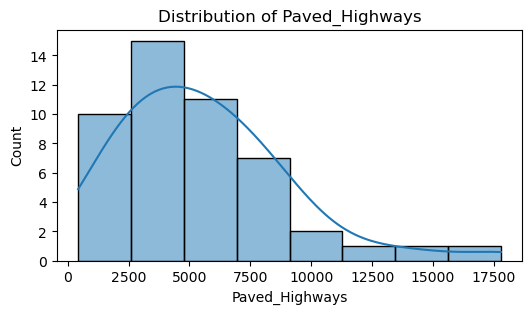

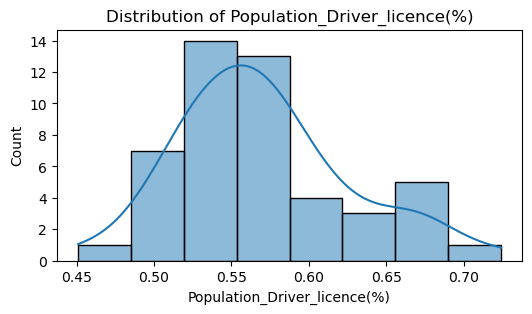

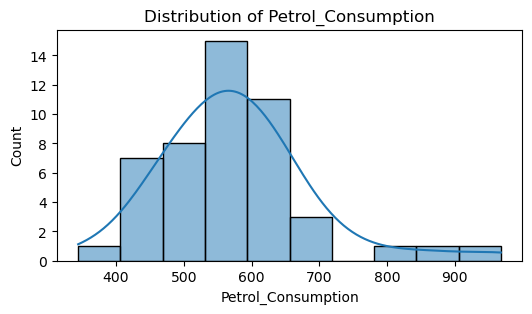

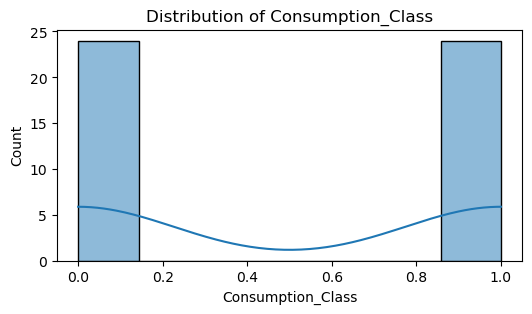

In [16]:
num_cols_all = df.select_dtypes(include=np.number).columns
for col in num_cols_all:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

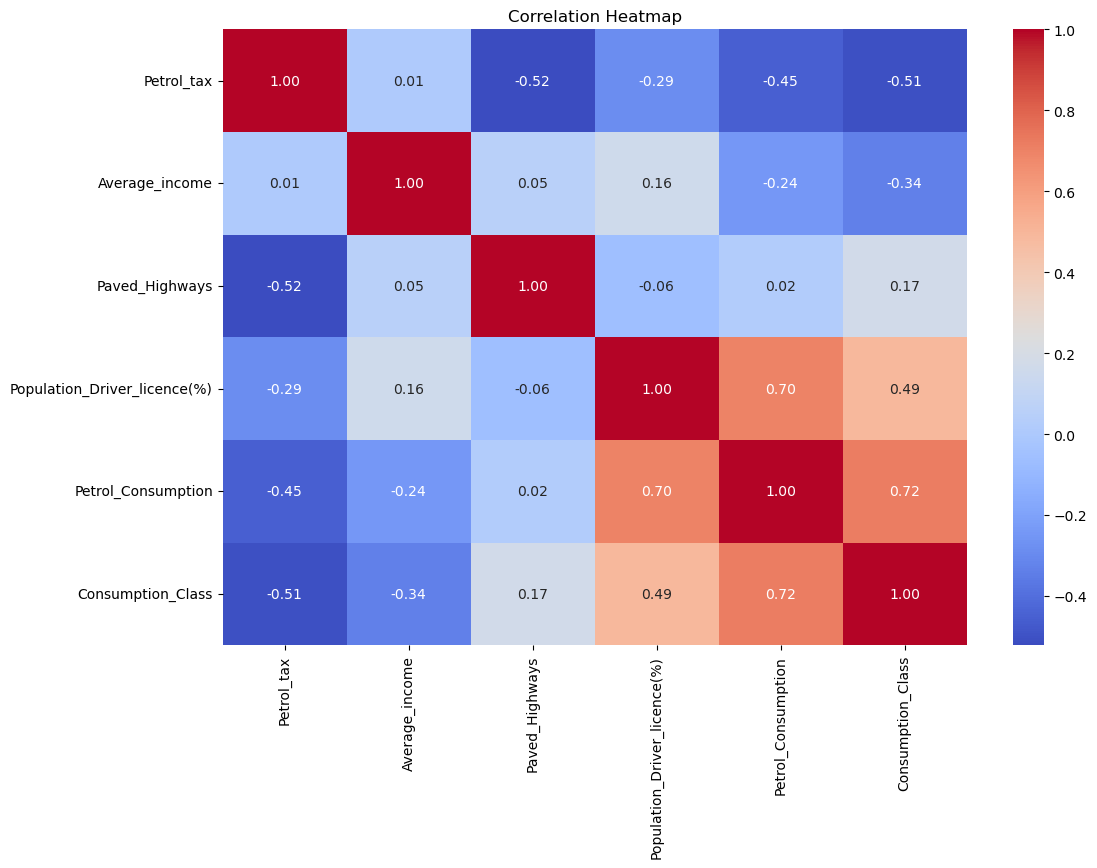

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

<h2 style="color:#2E86C1;">
6️⃣ 📈 Analysis Data
</h2>

<h2 style="color:#2E86C1;">
📊 Consumption KPI :
</h2>

In [18]:
Total_Records   = df.shape[0]
Total_High      = df['Consumption_Class'].sum()
Total_Low       = Total_Records - Total_High
High_Rate       = (Total_High / Total_Records) * 100
Avg_Tax         = df['Petrol_tax'].mean()
Avg_Income      = df['Average_income'].mean()
Avg_Highways    = df['Paved_Highways'].mean()
Avg_License     = df['Population_Driver_licence(%)'].mean() * 100
Avg_Consumption = df['Petrol_Consumption'].mean()
Median_Consumption = df['Petrol_Consumption'].median()

print('='*60)
print('  CONSUMPTION KPIs')
print('='*60)
print(f'  Total Records          : {Total_Records:,}')
print(f'  High Consumption       : {Total_High:,}')
print(f'  Low  Consumption       : {Total_Low:,}')
print(f'  High Rate              : {High_Rate:.1f}%')
print(f'  Median Consumption     : {Median_Consumption:.1f}  (split threshold)')
print(f'  Avg Petrol Tax         : {Avg_Tax:.2f}')
print(f'  Avg Average Income     : {Avg_Income:,.0f}')
print(f'  Avg Paved Highways     : {Avg_Highways:,.0f}')
print(f'  Avg Driver Licence (%) : {Avg_License:.2f}%')
print(f'  Avg Petrol Consumption : {Avg_Consumption:.1f}')
print('='*60)

  CONSUMPTION KPIs
  Total Records          : 48
  High Consumption       : 24
  Low  Consumption       : 24
  High Rate              : 50.0%
  Median Consumption     : 568.5  (split threshold)
  Avg Petrol Tax         : 7.67
  Avg Average Income     : 4,242
  Avg Paved Highways     : 5,565
  Avg Driver Licence (%) : 57.03%
  Avg Petrol Consumption : 576.8


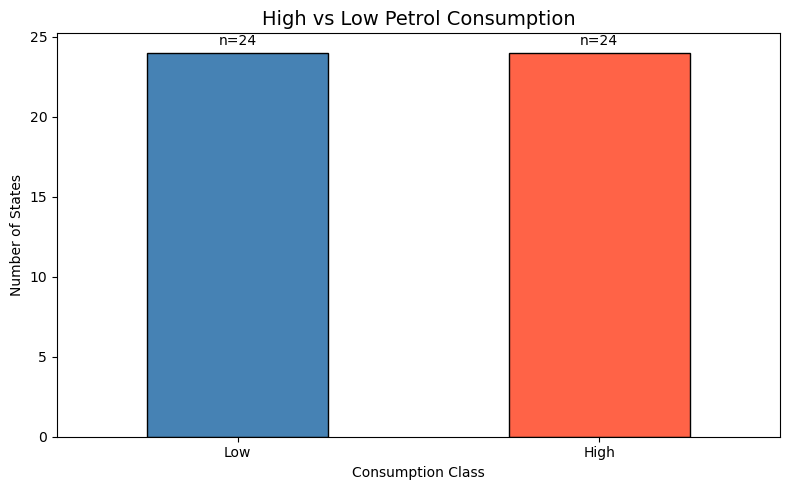

In [69]:
cons_counts = df['consumption_label'].value_counts()
ax = cons_counts.plot(
    kind='bar',
    color=['steelblue', 'tomato'],
    edgecolor='black',
    figsize=(8, 5)
)
plt.title('High vs Low Petrol Consumption', fontsize=14)
plt.xlabel('Consumption Class')
plt.ylabel('Number of States')
plt.xticks(rotation=0)
ax.bar_label(
    ax.containers[0],
    labels=[f'n={c:,}' for c in cons_counts],
    label_type='edge',
    padding=3
)
plt.tight_layout()
plt.show()

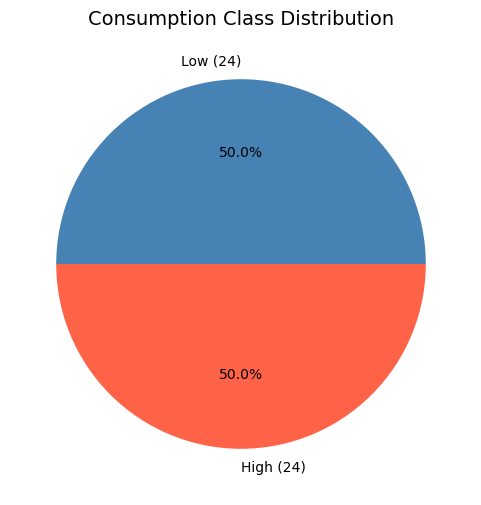

In [20]:
cons_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6, 6),
    colors=['steelblue', 'tomato'],
    labels=[f'{cons_counts.index[i]} ({cons_counts.iloc[i]})' for i in range(len(cons_counts))]
)
plt.title('Consumption Class Distribution', fontsize=14)
plt.ylabel('')
plt.show()

💡 Insight :

1) ⚖️ Balanced split by design → 50% High / 50% Low (median threshold)

2) ✅ No class imbalance issue → ideal for Decision Tree Classifier

3) Understanding what drives high consumption helps with policy and fuel tax decisions


In [70]:
feature_kpi = df.groupby('consumption_label').agg(
    Avg_Petrol_Tax   =('Petrol_tax',                    'mean'),
    Avg_Income       =('Average_income',                 'mean'),
    Avg_Highways     =('Paved_Highways',                 'mean'),
    Avg_License_Pct  =('Population_Driver_licence(%)',   'mean'),
    Avg_Consumption  =('Petrol_Consumption',             'mean')
).round(2)
feature_kpi

,Avg_Petrol_Tax,Avg_Income,Avg_Highways,Avg_License_Pct,Avg_Consumption
consumption_label,,,,,
High,7.19,4050.42,6153.79,0.60,656.21
Low,8.15,4433.25,4977.04,0.54,497.33


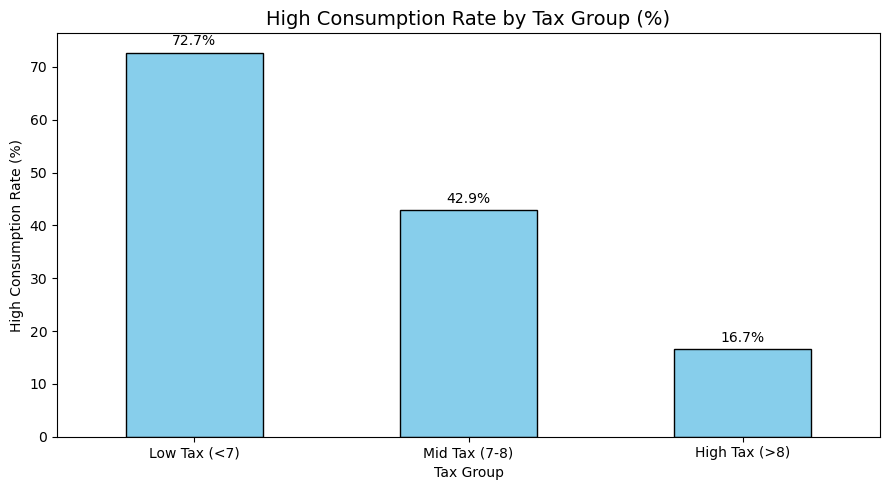

In [71]:
cons_tax = df.groupby('tax_group', observed=True)['Consumption_Class'].mean() * 100
ax = cons_tax.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black',
    figsize=(9, 5)
)
plt.title('High Consumption Rate by Tax Group (%)', fontsize=14)
plt.xlabel('Tax Group')
plt.ylabel('High Consumption Rate (%)')
plt.xticks(rotation=0)
ax.bar_label(
    ax.containers[0],
    labels=[f'{c:.1f}%' for c in cons_tax],
    padding=3
)
plt.tight_layout()
plt.show()

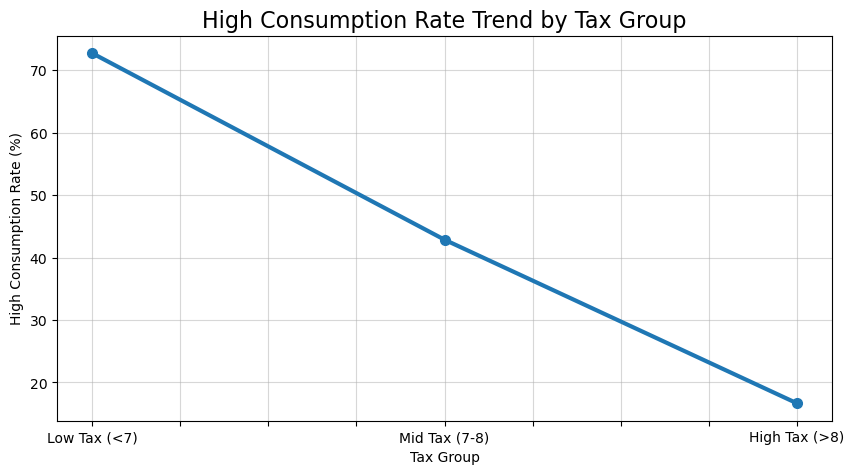

In [23]:
cons_tax.plot(
    kind='line',
    marker='o',
    ms=7,
    linewidth=3,
    figsize=(10, 5)
)
plt.title('High Consumption Rate Trend by Tax Group', fontsize=16)
plt.xlabel('Tax Group')
plt.ylabel('High Consumption Rate (%)')
plt.grid(alpha=0.5)
plt.show()

<h2 style="color:#2E86C1;">
📊 Income Level KPI
</h2>

In [72]:
income_kpi = df.groupby('income_level', observed=True).agg(
    Records         =('Consumption_Class', 'count'),
    High_Consumption=('Consumption_Class', 'sum'),
    High_Rate       =('Consumption_Class', 'mean'),
    Avg_Tax         =('Petrol_tax',         'mean'),
    Avg_Highways    =('Paved_Highways',     'mean'),
    Avg_Consumption =('Petrol_Consumption', 'mean')
).reset_index().sort_values('High_Consumption', ascending=False)
income_kpi['High_Rate'] = (income_kpi['High_Rate'] * 100).round(2)
income_kpi

,income_level,Records,High_Consumption,High_Rate,Avg_Tax,Avg_Highways,Avg_Consumption
1,Mid (4-5K),25,12,48.00,7.580000,5665.920000,576.520000
0,Low (<4K),17,11,64.71,7.769412,4933.588235,601.588235
2,Upper-Mid (5-6K),6,1,16.67,7.750000,6936.833333,507.500000


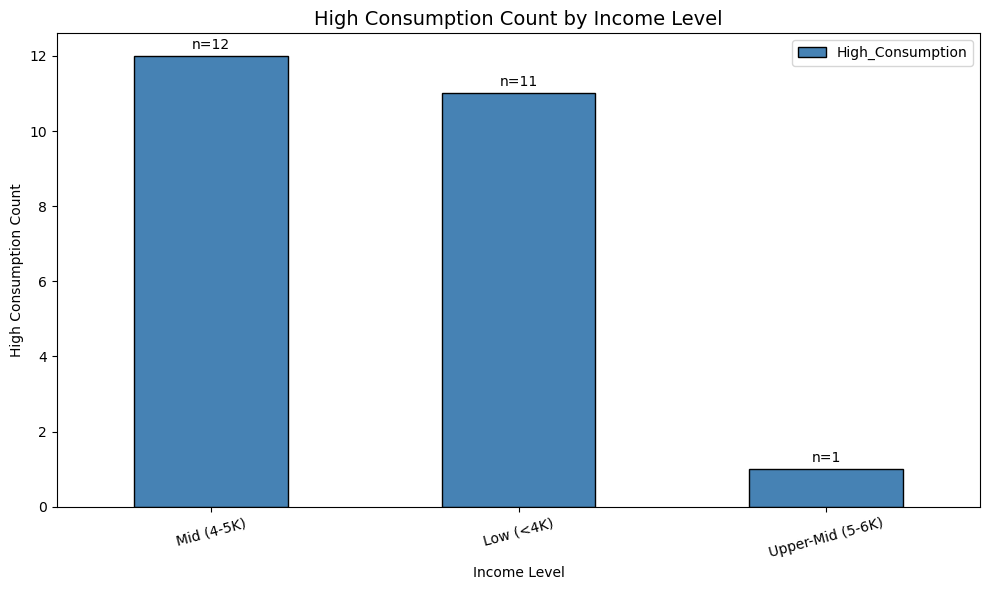

In [73]:
ax = income_kpi.plot(
    kind='bar',
    x='income_level',
    y='High_Consumption',
    color='steelblue',
    edgecolor='black',
    figsize=(10, 6)
)
plt.title('High Consumption Count by Income Level', fontsize=14)
plt.xlabel('Income Level')
plt.ylabel('High Consumption Count')
ax.bar_label(
    ax.containers[0],
    labels=[f'n={c:,}' for c in income_kpi['High_Consumption']],
    label_type='edge',
    padding=3
)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

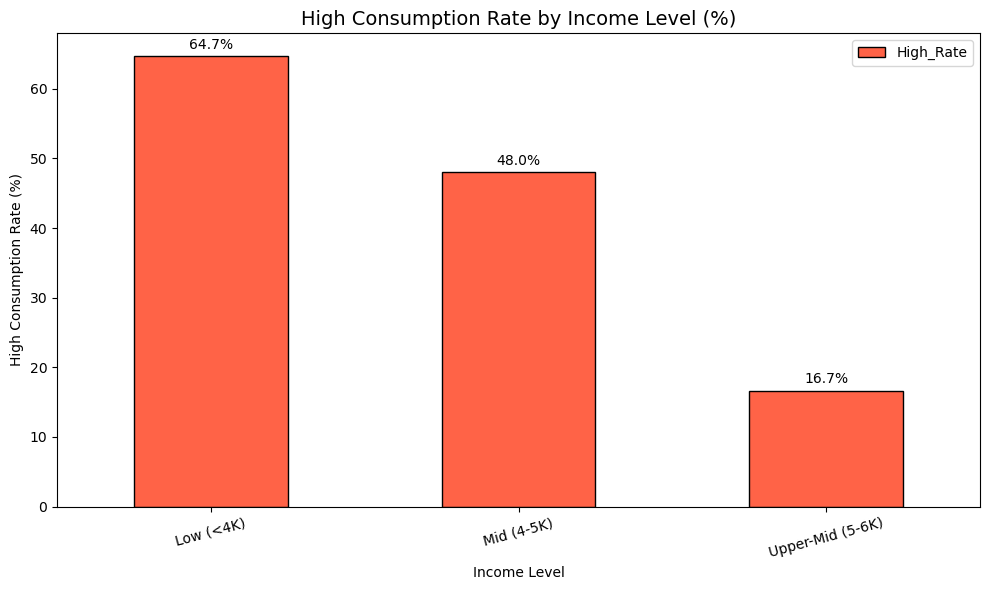

In [74]:
income_rate = income_kpi.sort_values('High_Rate', ascending=False)
ax = income_rate.plot(
    kind='bar',
    x='income_level',
    y='High_Rate',
    color='tomato',
    edgecolor='black',
    figsize=(10, 6)
)
plt.title('High Consumption Rate by Income Level (%)', fontsize=14)
plt.xlabel('Income Level')
plt.ylabel('High Consumption Rate (%)')
ax.bar_label(
    ax.containers[0],
    labels=[f'{c:.1f}%' for c in income_rate['High_Rate']],
    label_type='edge',
    padding=3
)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

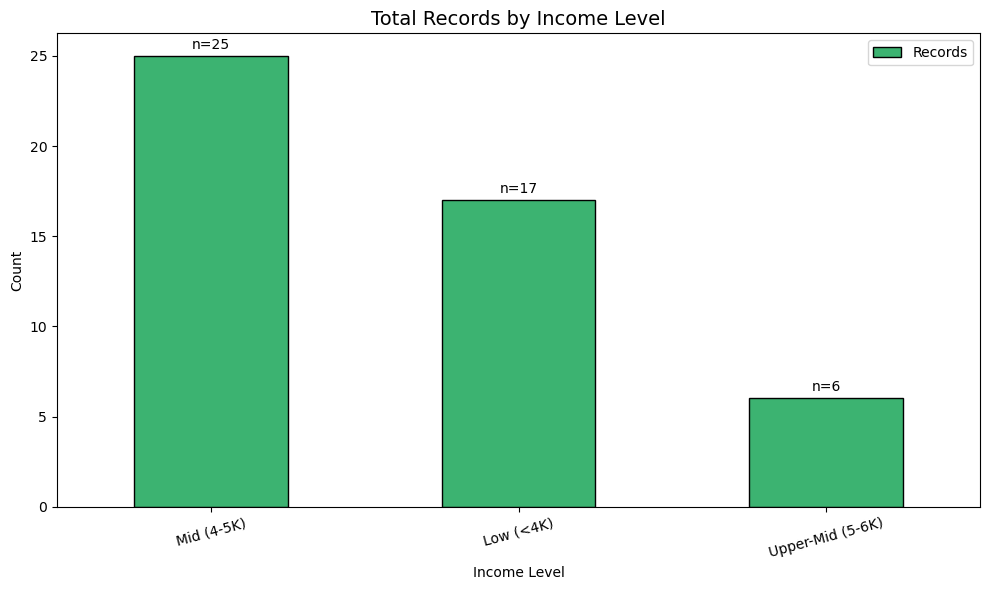

In [75]:
income_count = income_kpi.sort_values('Records', ascending=False)
ax = income_count.plot(
    kind='bar',
    x='income_level',
    y='Records',
    color='mediumseagreen',
    edgecolor='black',
    figsize=(10, 6)
)
plt.title('Total Records by Income Level', fontsize=14)
plt.xlabel('Income Level')
plt.ylabel('Count')
ax.bar_label(
    ax.containers[0],
    labels=[f'n={c:,}' for c in income_count['Records']],
    label_type='edge',
    padding=3
)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

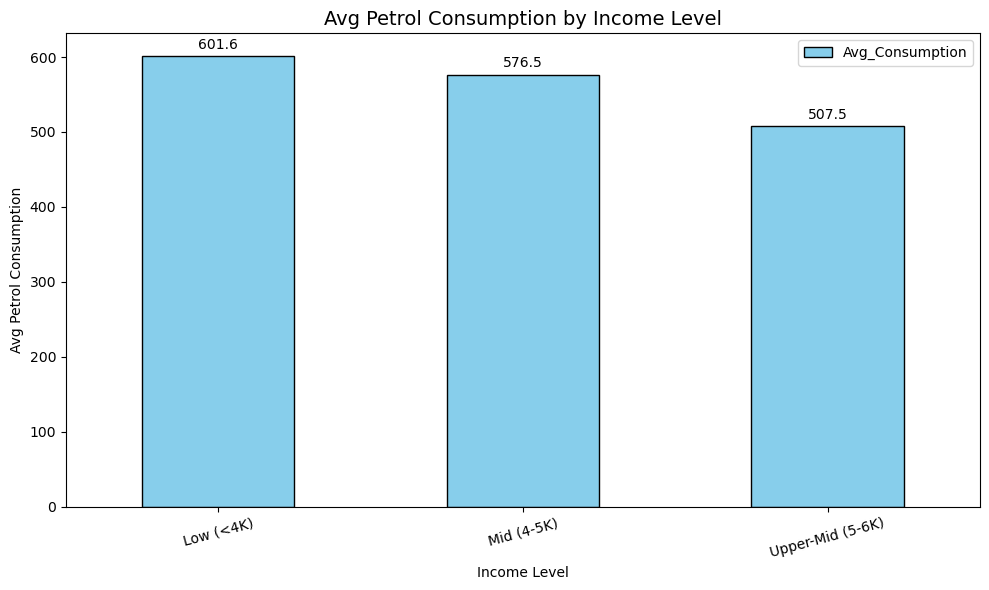

In [76]:
avg_cons_income = income_kpi.sort_values('Avg_Consumption', ascending=False)
ax = avg_cons_income.plot(
    kind='bar',
    x='income_level',
    y='Avg_Consumption',
    color='skyblue',
    edgecolor='black',
    figsize=(10, 6)
)
plt.title('Avg Petrol Consumption by Income Level', fontsize=14)
plt.xlabel('Income Level')
plt.ylabel('Avg Petrol Consumption')
ax.bar_label(
    ax.containers[0],
    labels=[f'{c:.1f}' for c in avg_cons_income['Avg_Consumption']],
    label_type='edge',
    padding=3
)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

💡 Insight :

1) 📈 Higher income states tend to consume more petrol — more cars, more travel

2) 📊 Lower income brackets show lower consumption — affordability constraint

3) Income level is a strong predictor of petrol consumption class

4) Tax policy in high-income states may be more effective at reducing consumption


<h2 style="color:#2E86C1;">
📊 Highway & Driver Licence KPI
</h2>

In [77]:
highway_kpi = df.groupby('highway_level', observed=True).agg(
    Records         =('Consumption_Class', 'count'),
    High_Consumption=('Consumption_Class', 'sum'),
    High_Rate       =('Consumption_Class', 'mean'),
    Avg_Income      =('Average_income',    'mean'),
    Avg_Consumption =('Petrol_Consumption','mean')
).reset_index().sort_values('High_Consumption', ascending=False)
highway_kpi['High_Rate'] = (highway_kpi['High_Rate'] * 100).round(2)
highway_kpi

,highway_level,Records,High_Consumption,High_Rate,Avg_Income,Avg_Consumption
1,Mid (3-6K),17,12,70.59,4004.882353,630.941176
2,High (6-9K),13,7,53.85,4091.538462,577.153846
3,Very High (>9K),6,3,50.00,4609.333333,540.833333
0,Low (<3K),12,2,16.67,4556.583333,517.583333


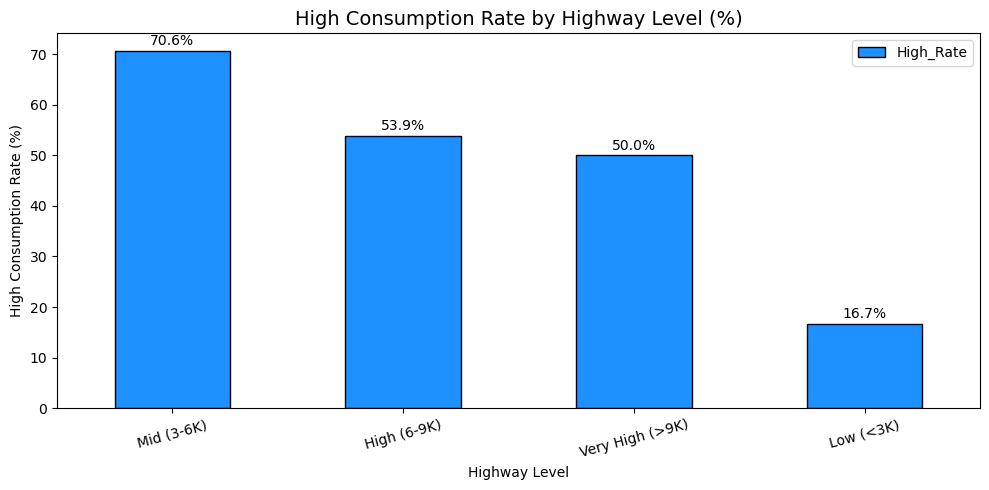

In [78]:
ax = highway_kpi.plot(
    kind='bar',
    x='highway_level',
    y='High_Rate',
    color='dodgerblue',
    edgecolor='black',
    figsize=(10, 5)
)
plt.title('High Consumption Rate by Highway Level (%)', fontsize=14)
plt.xlabel('Highway Level')
plt.ylabel('High Consumption Rate (%)')
plt.xticks(rotation=15)
ax.bar_label(
    ax.containers[0],
    labels=[f'{c:.1f}%' for c in highway_kpi['High_Rate']],
    padding=2
)
plt.tight_layout()
plt.show()

In [79]:
license_kpi = df.groupby('license_level', observed=True).agg(
    Records         =('Consumption_Class', 'count'),
    High_Consumption=('Consumption_Class', 'sum'),
    High_Rate       =('Consumption_Class', 'mean'),
    Avg_Income      =('Average_income',    'mean'),
    Avg_Consumption =('Petrol_Consumption','mean')
).reset_index().sort_values('High_Consumption', ascending=False)
license_kpi['High_Rate'] = (license_kpi['High_Rate'] * 100).round(2)
license_kpi

,license_level,Records,High_Consumption,High_Rate,Avg_Income,Avg_Consumption
3,Very High (>60%),12,10,83.33,4417.250000,677.583333
2,High (55-60%),17,8,47.06,4295.588235,564.058824
1,Mid (50-55%),16,6,37.50,4070.500000,537.500000
0,Low (<50%),3,0,0.00,4149.333333,455.000000


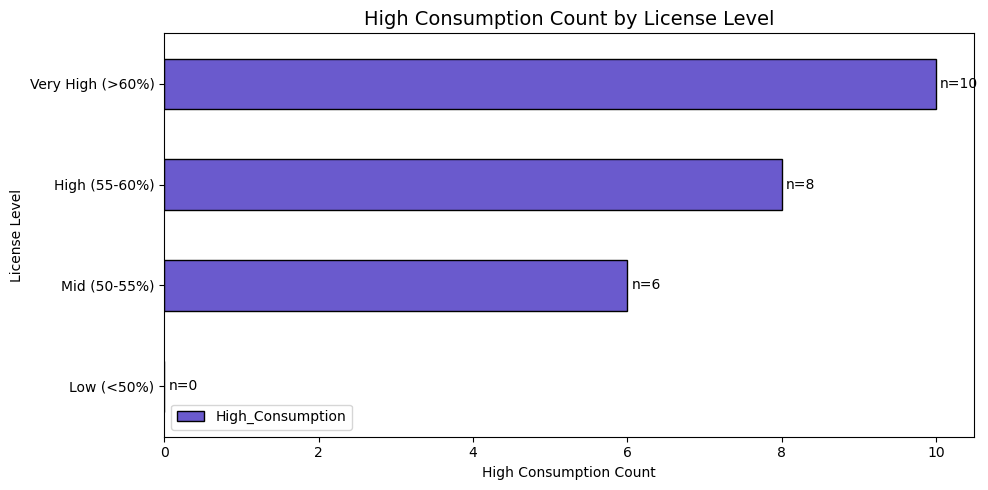

In [80]:
ax = license_kpi.sort_values('High_Consumption', ascending=True).plot(
    kind='barh',
    x='license_level',
    y='High_Consumption',
    color='slateblue',
    edgecolor='black',
    figsize=(10, 5)
)
plt.title('High Consumption Count by License Level', fontsize=14)
plt.xlabel('High Consumption Count')
plt.ylabel('License Level')
ax.bar_label(
    ax.containers[0],
    labels=[f'n={c:,}' for c in license_kpi.sort_values('High_Consumption')['High_Consumption']],
    padding=3
)
plt.tight_layout()
plt.show()

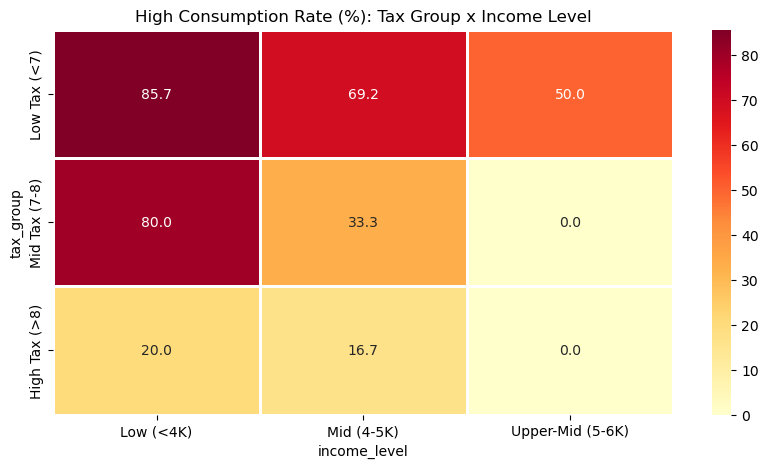

In [81]:
tax_income = df.groupby(['tax_group', 'income_level'], observed=True)['Consumption_Class'].mean().reset_index()
tax_income['High_Rate'] = (tax_income['Consumption_Class'] * 100).round(1)
pivot_ti = tax_income.pivot(index='tax_group', columns='income_level', values='High_Rate').fillna(0)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_ti, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=2)
plt.title('High Consumption Rate (%): Tax Group x Income Level')
plt.show()

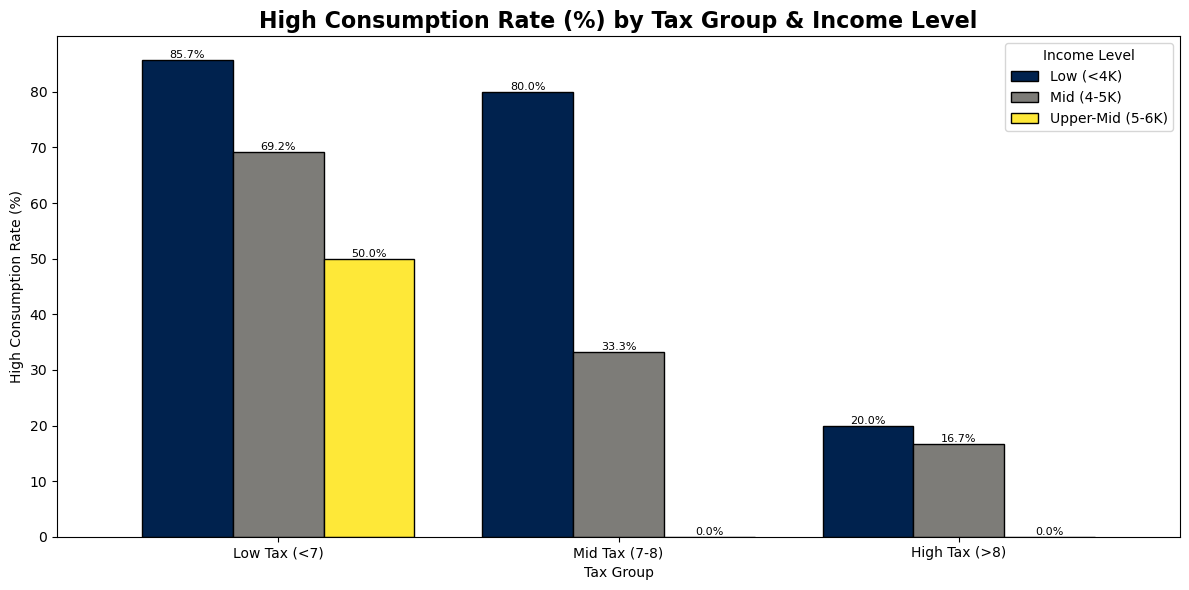

In [82]:
ax = pivot_ti.plot(
    kind='bar',
    figsize=(12, 6),
    edgecolor='black',
    width=0.8,
    colormap='cividis'
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8)
plt.title('High Consumption Rate (%) by Tax Group & Income Level', fontsize=16, weight='bold')
plt.xlabel('Tax Group')
plt.ylabel('High Consumption Rate (%)')
plt.legend(title='Income Level', bbox_to_anchor=(1.0, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [83]:
pivot_ti

income_level,Low (<4K),Mid (4-5K),Upper-Mid (5-6K)
tax_group,,,
Low Tax (<7),85.7,69.2,50.0
Mid Tax (7-8),80.0,33.3,0.0
High Tax (>8),20.0,16.7,0.0


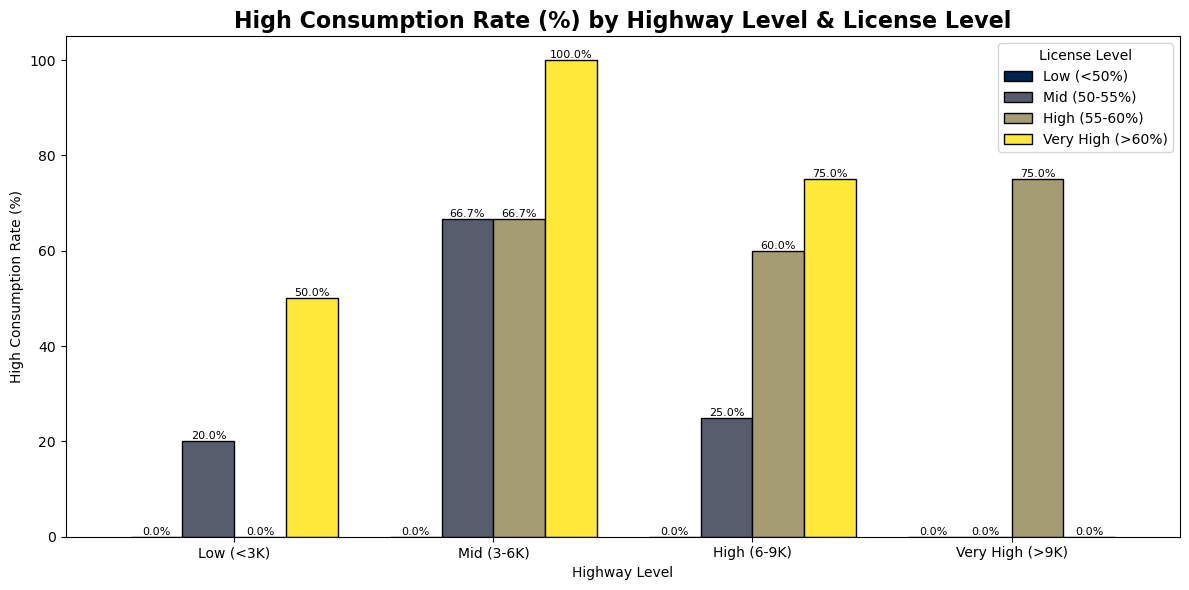

In [84]:
hw_lic = df.groupby(['highway_level', 'license_level'], observed=True)['Consumption_Class'].mean().reset_index()
hw_lic['High_Rate'] = (hw_lic['Consumption_Class'] * 100).round(1)
pivot_hl = hw_lic.pivot(index='highway_level', columns='license_level', values='High_Rate').fillna(0)

ax = pivot_hl.plot(
    kind='bar',
    figsize=(12, 6),
    edgecolor='black',
    width=0.8,
    colormap='cividis'
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8)
plt.title('High Consumption Rate (%) by Highway Level & License Level', fontsize=16, weight='bold')
plt.xlabel('Highway Level')
plt.ylabel('High Consumption Rate (%)')
plt.legend(title='License Level', bbox_to_anchor=(1.0, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [85]:
pivot_hl

license_level,Low (<50%),Mid (50-55%),High (55-60%),Very High (>60%)
highway_level,,,,
Low (<3K),0.0,20.0,0.0,50.0
Mid (3-6K),0.0,66.7,66.7,100.0
High (6-9K),0.0,25.0,60.0,75.0
Very High (>9K),0.0,0.0,75.0,0.0


In [86]:
top_tax_group     = df.groupby('tax_group',    observed=True)['Consumption_Class'].mean().idxmax()
top_income_level  = df.groupby('income_level',  observed=True)['Consumption_Class'].mean().idxmax()
top_highway_level = df.groupby('highway_level', observed=True)['Consumption_Class'].mean().idxmax()
top_license_level = df.groupby('license_level', observed=True)['Consumption_Class'].mean().idxmax()
avg_high_income   = df[df['Consumption_Class'] == 1]['Average_income'].mean()
avg_low_income    = df[df['Consumption_Class'] == 0]['Average_income'].mean()

insights = [
    ('⛽ Highest Consumption Tax Group',    f'{top_tax_group} has the highest high-consumption rate.'),
    ('💰 Highest Consumption Income Level', f'{top_income_level} income states consume the most petrol.'),
    ('🛣️ Highest Consumption Highway Level',f'{top_highway_level} highway states show highest consumption.'),
    ('🚗 Highest Consumption License Level',f'{top_license_level} license rate correlates with high consumption.'),
    ('📊 Avg Income (High Consumers)',       f'High consumers average income: {avg_high_income:,.0f}'),
    ('📊 Avg Income (Low Consumers)',        f'Low  consumers average income: {avg_low_income:,.0f}'),
    ('📈 Income vs Consumption',             'Higher income → more cars → higher petrol consumption.'),
    ('🛣️ Highways vs Consumption',          'More paved roads correlate with higher fuel usage.'),
]

print('='*65)
print('  KEY INSIGHTS & STRATEGIC TAKEAWAYS')
print('='*65)
for title, detail in insights:
    print(f'  {title}')
    print(f'     -> {detail}')
    print()
print('RECOMMENDATIONS')
print('-'*65)
recs = [
    f'1. Target fuel tax policy on {top_income_level} income states for maximum impact.',
    f'2. Monitor {top_highway_level} highway states — high road supply drives consumption.',
    '3. Increase petrol tax in high-income, high-license states to curb demand.',
    '4. Invest in public transport in states with high driver licence rates.',
    '5. Deploy Decision Tree Classifier to predict consumption class in real time.',
    '6. Combine income & highway data for a more precise policy intervention model.',
]
for r in recs:
    print(f'  {r}')
print('='*65)

  KEY INSIGHTS & STRATEGIC TAKEAWAYS
  ⛽ Highest Consumption Tax Group
     -> Low Tax (<7) has the highest high-consumption rate.

  💰 Highest Consumption Income Level
     -> Low (<4K) income states consume the most petrol.

  🛣️ Highest Consumption Highway Level
     -> Mid (3-6K) highway states show highest consumption.

  🚗 Highest Consumption License Level
     -> Very High (>60%) license rate correlates with high consumption.

  📊 Avg Income (High Consumers)
     -> High consumers average income: 4,050

  📊 Avg Income (Low Consumers)
     -> Low  consumers average income: 4,433

  📈 Income vs Consumption
     -> Higher income → more cars → higher petrol consumption.

  🛣️ Highways vs Consumption
     -> More paved roads correlate with higher fuel usage.

RECOMMENDATIONS
-----------------------------------------------------------------
  1. Target fuel tax policy on Low (<4K) income states for maximum impact.
  2. Monitor Mid (3-6K) highway states — high road supply drives consum

<h2 style="color:#2E86C1;">
7️⃣ 🤖 Decision Tree Classifier Model
</h2>

<h2 style="color:#2E86C1;">
 🔧 Define Features & Target
</h2>

In [87]:
FEATURES = [
    'Petrol_tax',
    'Average_income',
    'Paved_Highways',
    'Population_Driver_licence(%)'
]
TARGET = 'Consumption_Class'

num_cols = FEATURES   # all features are numerical
cat_cols = []         # no categorical columns

print('='*55)
print('  FEATURE SETUP')
print('='*55)
print(f'  Features  ({len(FEATURES)}) : {FEATURES}')
print(f'  Target             : {TARGET}  (0=Low, 1=High)')
print('='*55)

  FEATURE SETUP
  Features  (4) : ['Petrol_tax', 'Average_income', 'Paved_Highways', 'Population_Driver_licence(%)']
  Target             : Consumption_Class  (0=Low, 1=High)


In [88]:
X = df[FEATURES]
y = df[TARGET]
print(f'📌 X shape : {X.shape}')
print(f'📌 y shape : {y.shape}')

📌 X shape : (48, 4)
📌 y shape : (48,)


## ✂️ Train-Test Split

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('='*45)
print('  TRAIN / TEST SPLIT')
print('='*45)
print(f'  Training samples : {X_train.shape[0]}')
print(f'  Test     samples : {X_test.shape[0]}')
print(f'  Test size        : 20%')
print(f'  Stratified       : Yes')
print('='*45)

  TRAIN / TEST SPLIT
  Training samples : 38
  Test     samples : 10
  Test size        : 20%
  Stratified       : Yes


<h2 style="color:#2E86C1;">️
⚙️ Build the Pipeline
</h2>

In [42]:
# ── Step 1 : Preprocessor ────────────────────────────────────
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, num_cols)
])

# ── Step 2 : Full Pipeline ───────────────────────────────────
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', DecisionTreeClassifier(random_state=42))
])

print('Pipeline built successfully!')

Pipeline built successfully!


## 📌 Hyperparameter Tuning

In [90]:
param_grid = {
    'clf__criterion'        : ['gini', 'entropy'],
    'clf__max_depth'        : list(range(1, 10)),
    'clf__min_samples_split': [2, 4, 6, 8],
    'clf__min_samples_leaf' : [1, 2, 3, 4]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'clf__criterion': ['gini', 'entropy'], 'clf__max_depth': [1, 2, ...], 'clf__min_samples_leaf': [1, 2, ...], 'clf__min_samples_split': [2, 4, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...)]"


## 📌 Best Model

In [91]:
print('Best Parameters:', grid.best_params_)
best_model = grid.best_estimator_

Best Parameters: {'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2}


## 📌 Predictions

In [92]:
y_pred       = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

## 📌 Evaluation

In [94]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred,
      target_names=['Low Consumption', 'High Consumption']))

Accuracy: 0.9

Classification Report:

                  precision    recall  f1-score   support

 Low Consumption       0.83      1.00      0.91         5
High Consumption       1.00      0.80      0.89         5

        accuracy                           0.90        10
       macro avg       0.92      0.90      0.90        10
    weighted avg       0.92      0.90      0.90        10



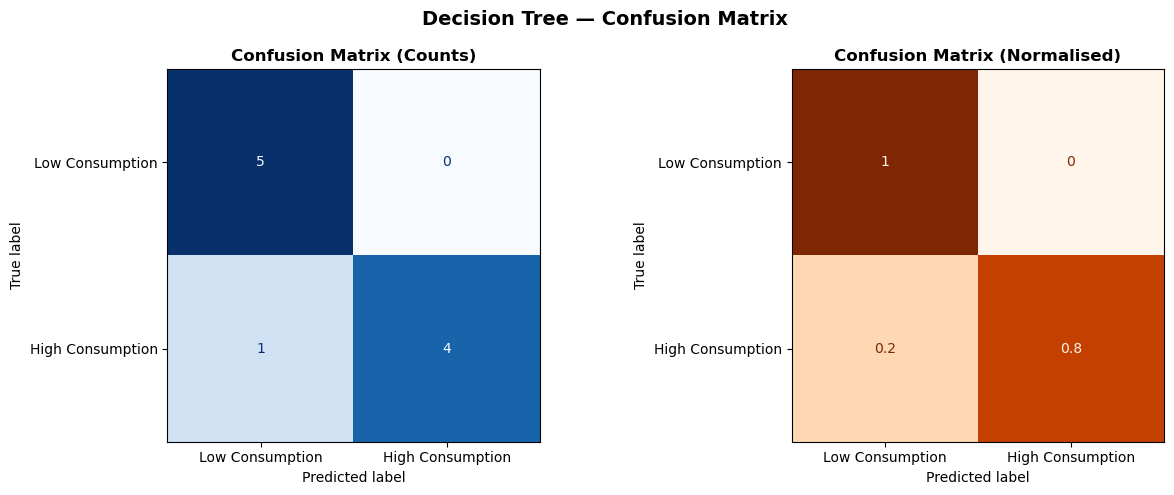

True  Positives (TP): 4
True  Negatives (TN): 5
False Positives (FP): 0
False Negatives (FN): 1


In [95]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

disp = ConfusionMatrixDisplay(cm,
       display_labels=['Low Consumption', 'High Consumption'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold', fontsize=12)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2   = ConfusionMatrixDisplay(cm_norm.round(2),
          display_labels=['Low Consumption', 'High Consumption'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold', fontsize=12)

plt.suptitle('Decision Tree — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print('True  Positives (TP):', tp)
print('True  Negatives (TN):', tn)
print('False Positives (FP):', fp)
print('False Negatives (FN):', fn)

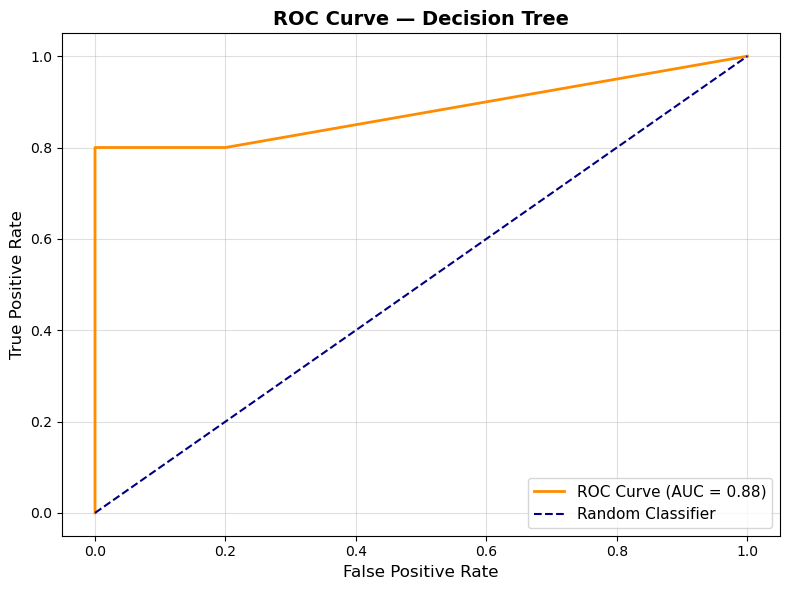

In [96]:
# ROC Curve
y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score   = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label='ROC Curve (AUC = {:.2f})'.format(auc_score))
plt.plot([0,1],[0,1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Decision Tree', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

In [98]:
train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test,  y_pred)
best_params = grid.best_params_

print('='*65)
print('  DECISION TREE CLASSIFIER — FINAL SUMMARY')
print('='*65)
print(f'  Model             : Decision Tree Classifier')
print(f'  Best Criterion    : {best_params["clf__criterion"]}')
print(f'  Best Max Depth    : {best_params["clf__max_depth"]}')
print(f'  Min Samples Split : {best_params["clf__min_samples_split"]}')
print(f'  Min Samples Leaf  : {best_params["clf__min_samples_leaf"]}')
print(f'  Scaler            : StandardScaler')
print(f'  Features          : {len(FEATURES)}  -> {FEATURES}')
print(f'  Train / Test      : 80% / 20%  (Stratified)')
print(f'  Train Accuracy    : {train_acc*100:.2f}%')
print(f'  Test  Accuracy    : {test_acc*100:.2f}%')
print(f'  ROC AUC           : {auc_score:.4f}')
print('='*65)

  DECISION TREE CLASSIFIER — FINAL SUMMARY
  Model             : Decision Tree Classifier
  Best Criterion    : gini
  Best Max Depth    : 5
  Min Samples Split : 2
  Min Samples Leaf  : 2
  Scaler            : StandardScaler
  Features          : 4  -> ['Petrol_tax', 'Average_income', 'Paved_Highways', 'Population_Driver_licence(%)']
  Train / Test      : 80% / 20%  (Stratified)
  Train Accuracy    : 92.11%
  Test  Accuracy    : 90.00%
  ROC AUC           : 0.8800


## 📌 Save Model

In [99]:
with open('dt_pipeline.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print('Model saved as dt_pipeline.pkl')

Model saved as dt_pipeline.pkl
